In [1]:
import torch    
import json 
from ptlpinns.models import model, transfer
from ptlpinns.perturbation import LPM, standard
from ptlpinns.odes import forcing, numerical, equations
import numpy as np
import math
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid

/home/jovyan/.conda/envs/python3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Load model

In [2]:
name = "underdamped_k12"

overdamped_path = f"/home/jovyan/PTL-PINNs/ptlpinns/models/train/{name}"
overdamped_name = f"model_{name}.pth"
overdamped_model, training_log = model.load_model(overdamped_path, overdamped_name)

12 True True True 1.0 16 [128, 128, 256]


### Problem definition

In [3]:
N = 512
t_span = (0, 10)
t_eval = np.linspace(t_span[0], t_span[1], N)

### Compute latent representations

In [4]:
H_dict = transfer.compute_H_dict(overdamped_model, N=N, bias=True, t_span=t_span)

### Transfer parameters

In [5]:
w_list_transfer = [1, 1, 1]
zeta_list = [0.25, 0.5, 0.7]

def forcing(numpy=False):
    if not numpy:
        def force(t):
            return torch.stack((torch.zeros_like(t), torch.cos(t)), dim=1)
    else:
        def force(t):
            return np.stack((np.zeros_like(t), np.cos(t)), axis=1)
    return force

forcing_list = [forcing(True), forcing(True), forcing(True), forcing(True), forcing(True)]

forcing_1D = lambda t: np.cos(t)
ic_list = [[1, 0], [1, 0], [1, 0]]
epsilon_list = [0.5, 0.5, 0.5]
p_list = [6]
q = [(3, 1)]

### Numerical solver

In [6]:
numerical_list = []

for zeta in zeta_list:
    ode = equations.ode_oscillator_1D(w_0=w_list_transfer[0], zeta=zeta, forcing_1D=forcing_1D, q=q, epsilon=epsilon_list[0])
    numerical_list.append(numerical.solve_ode_equation(ode, (t_eval[0], t_eval[-1]), t_eval, ic_list[0]))

### PINN

In [7]:
NN_TL_solution, perturbation_solution, _ = transfer.compute_perturbation_solution(w_list_transfer, zeta_list, epsilon_list, p_list, ic_list, forcing_list, H_dict, t_eval, training_log, all_p=True, comp_time=False, solver="standard", power=q)
NN_TL_solution = NN_TL_solution.squeeze()

In [8]:
NN_TL_solution.shape

(512, 3, 2)

In [9]:
PINN_solution = []

for perturbation_zeta in perturbation_solution:

    perturbation = []
    for perturbation_order in perturbation_zeta:

        perturbation.append(perturbation_order[:, 0])

    PINN_solution.append(standard.calculate_general_series(perturbation, epsilon_list[0]))

zeta: 0.25, order: 0, mean error absolute: 0.4786307334475824
zeta: 0.25, order: 1, mean error absolute: 0.6510273989151018
zeta: 0.25, order: 2, mean error absolute: 0.7777222263271341
zeta: 0.25, order: 3, mean error absolute: 1.0346767831232742
zeta: 0.25, order: 4, mean error absolute: 2.177444335216909
zeta: 0.25, order: 5, mean error absolute: 4.441707281609509


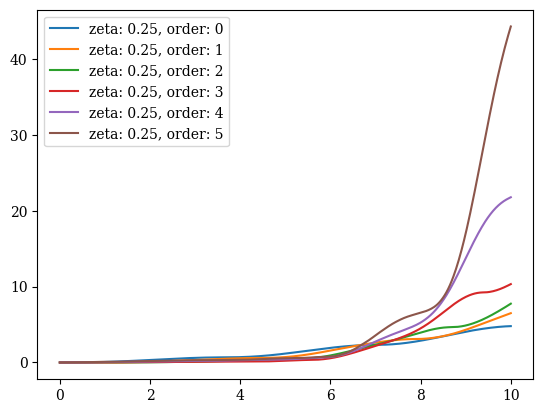

zeta: 0.5, order: 0, mean error absolute: 0.17869212549554248
zeta: 0.5, order: 1, mean error absolute: 0.08586624640981834
zeta: 0.5, order: 2, mean error absolute: 0.0403016151889639
zeta: 0.5, order: 3, mean error absolute: 0.03620189781093946
zeta: 0.5, order: 4, mean error absolute: 0.0232518500056009
zeta: 0.5, order: 5, mean error absolute: 0.019475200795237478


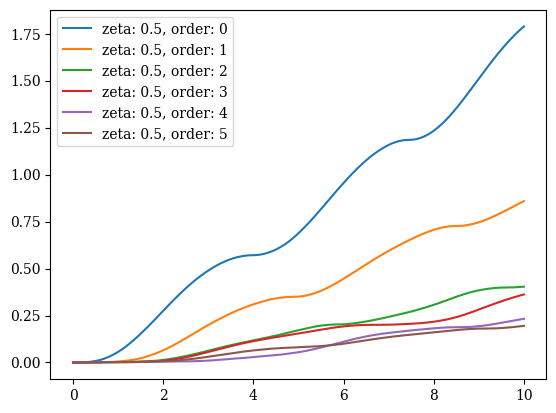

zeta: 0.7, order: 0, mean error absolute: 0.09523719636098685
zeta: 0.7, order: 1, mean error absolute: 0.03960361705930708
zeta: 0.7, order: 2, mean error absolute: 0.01905538926548423
zeta: 0.7, order: 3, mean error absolute: 0.01555090303536581
zeta: 0.7, order: 4, mean error absolute: 0.011011378581598626
zeta: 0.7, order: 5, mean error absolute: 0.009812712136810488


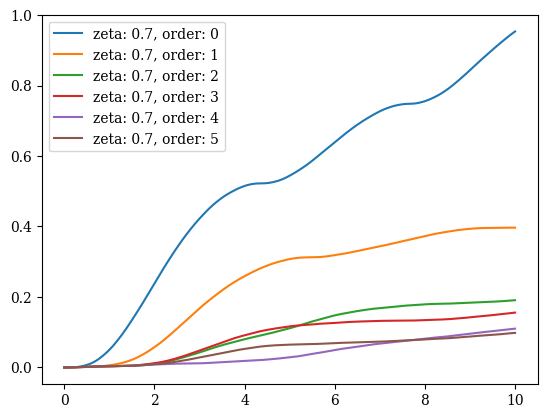

In [10]:
standard.plot_error_by_order(t_eval, PINN_solution, numerical_list, p_list, zeta_list, "zeta")

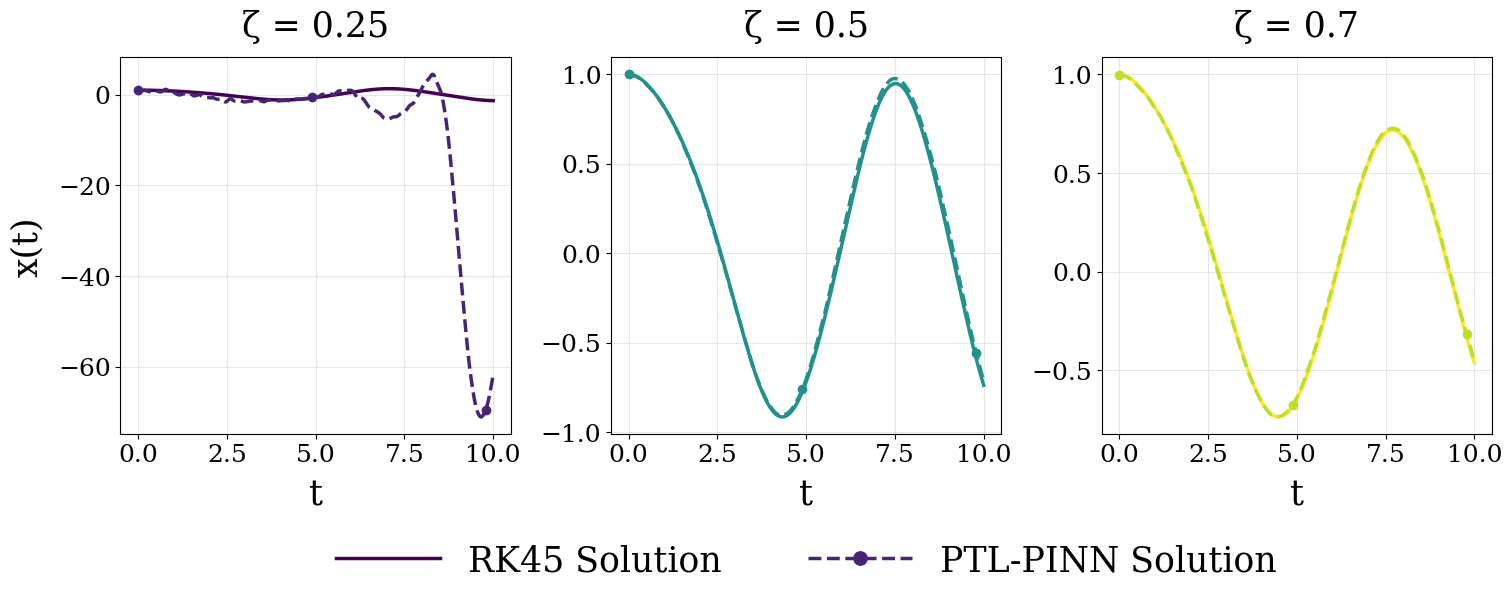

In [11]:
standard.plot_compare_multiple_zeta(t_eval, zeta_list, numerical_list, NN_TL_solution)


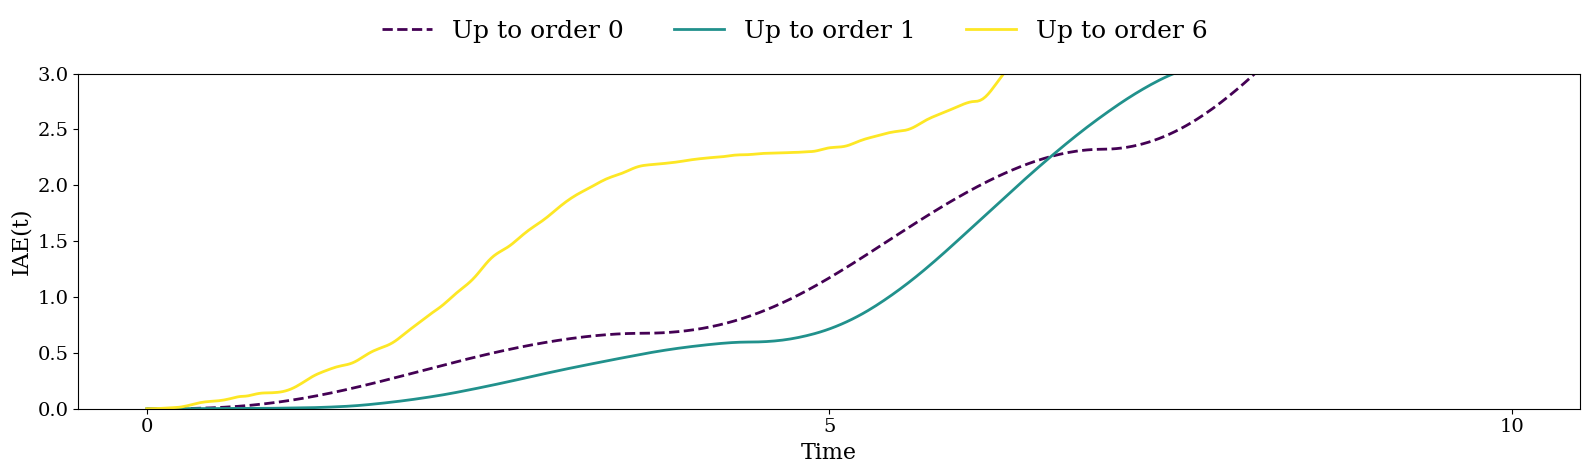

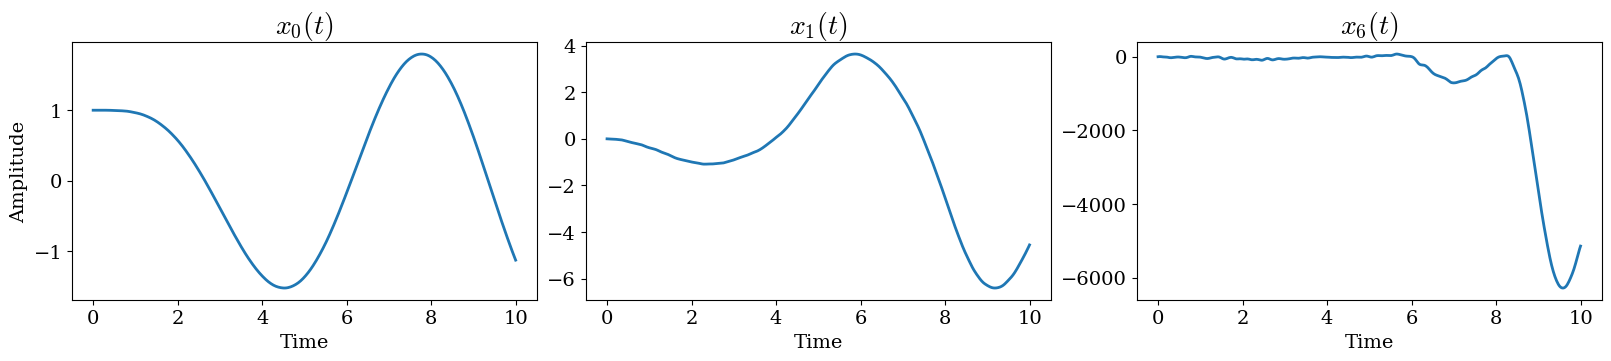

In [12]:
perturbation_solution_show = perturbation_solution[0]

PINN_x_solution = [perturbation_solution_show[i][:, 0] for i in range(len(perturbation_solution_show))]
PINN_x_solution = standard.calculate_general_series(PINN_x_solution, epsilon=epsilon_list[0])

standard.plot_IAE_and_subplots(PINN_x_solution, numerical_list[0], perturbation_solution_show, t_eval, selected_orders=[0, 1, 6], ylim=(0, 3))

/tmp/ipykernel_2223900/3129563047.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis", 3)


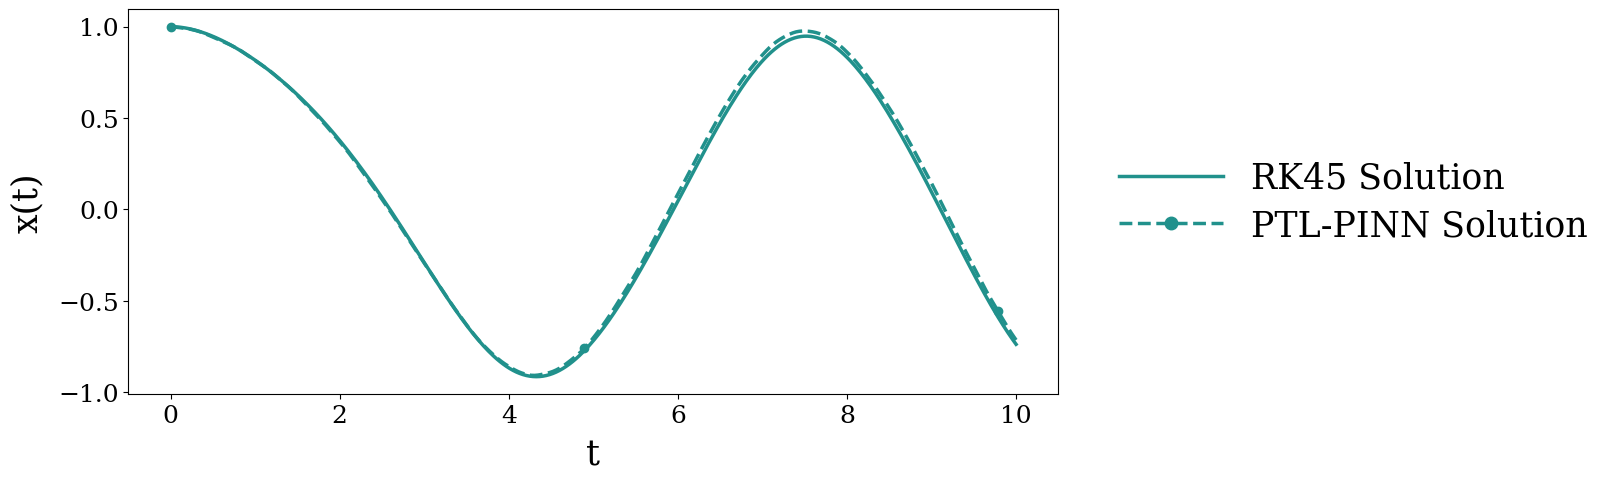

In [13]:
import matplotlib.cm as cm

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],
    "mathtext.fontset": "cm",
    "text.usetex": False,
})

def plot_solution(t_eval, y_num, y_nn, i = 0):
    title_fs  = 25
    label_fs  = 25
    tick_fs   = 18
    legend_fs = 25
    cmap = cm.get_cmap("viridis", 3)

    fig, ax = plt.subplots(figsize=(12, 5))

    base_color = cmap(i / 2)
    rk_color   = base_color
    pinn_color = cm.viridis(0.1 + 0.8 * i / 2)

    ax.plot(t_eval, y_num,
            label="RK45 Solution",
            color=rk_color, linewidth=2.5)

    ax.plot(t_eval, y_nn,
            label="PTL-PINN Solution",
            color=pinn_color, linewidth=2.5,
            linestyle="--", marker="o", markevery=250)

    ax.set_xlabel("t", fontsize=label_fs, labelpad=8)
    ax.set_ylabel("x(t)", fontsize=label_fs, labelpad=10)

    ax.tick_params(axis='both', labelsize=tick_fs)

    # Set y-limits with padding
    y_min = min(np.min(y_num), np.min(y_nn))
    y_max = max(np.max(y_num), np.max(y_nn))
    pad = 0.05 * max(1e-12, (y_max - y_min))
    ax.set_ylim(y_min - pad, y_max + pad)

    ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),  # (x, y): anchor the legend outside the right border
    fontsize=legend_fs,
    frameon=False,
    handlelength=3.0,
    markerscale=1.5,
    labelspacing=0.4,
    borderaxespad=0.8)
    plt.show()

plot_solution(t_eval, numerical_list[1][0, :], NN_TL_solution[:, 1, 0], i = 1)

In [14]:
ode_high_acc = equations.ode_oscillator_1D(w_0=1, zeta=0.5, forcing_1D=forcing_1D, q=q, epsilon=epsilon_list[0])
dt = (t_eval[1] - t_eval[0])/100
t_eval_high_acc = np.linspace(t_span[0], t_span[1], (t_eval.size - 1)*100 + 1)
num_high_acc = numerical.solve_ode_equation(ode_high_acc, (t_eval_high_acc[0], t_eval_high_acc[-1]), t_eval_high_acc, ic_list[0])[0, :]

In [15]:
error = []
for i in range(p_list[0]):
    error.append(np.mean(np.abs(PINN_solution[1][i] - num_high_acc[::100])))

In [16]:
error

[np.float64(0.17869212549554273),
 np.float64(0.08586624640981816),
 np.float64(0.040301615188963864),
 np.float64(0.03620189781093959),
 np.float64(0.023251850005600767),
 np.float64(0.01947520079523752)]

## H initialization ablation

Compare PTL-PINN accuracy when H is built from (a) the pretrained model, (b) a randomly
initialised model of identical architecture, and (c) a QR-orthogonalised version of (b).
MAE is averaged across all zeta values.

In [17]:
# ── H initialization ablation (underdamped, standard perturbation) ────────────

# 1. Random H
H_dict_random = transfer.compute_H_dict_random_init(training_log, N=N, bias=True, t_span=t_span)

# 2. Orthogonal H
H_dict_orth = transfer.compute_H_dict_orthogonal(H_dict_random)

# 3. PTL-PINN with random H
NN_sol_random, _, _ = transfer.compute_perturbation_solution(
    w_list_transfer, zeta_list, epsilon_list, p_list,
    ic_list, forcing_list, H_dict_random, t_eval, training_log,
    all_p=True, comp_time=False, solver="standard", power=q)
NN_sol_random = NN_sol_random.squeeze()

# 4. PTL-PINN with orthogonal H
NN_sol_orth, _, _ = transfer.compute_perturbation_solution(
    w_list_transfer, zeta_list, epsilon_list, p_list,
    ic_list, forcing_list, H_dict_orth, t_eval, training_log,
    all_p=True, comp_time=False, solver="standard", power=q)
NN_sol_orth = NN_sol_orth.squeeze()

# 5. Per-zeta MAE on x(t), then averaged
def mean_mae_across_zeta(sol, numerical_list):
    return np.mean([np.mean(np.abs(sol[:, i, 0] - numerical_list[i][0, :]))
                    for i in range(len(zeta_list))])

mae_pretrained = mean_mae_across_zeta(NN_TL_solution, numerical_list)
mae_random     = mean_mae_across_zeta(NN_sol_random,  numerical_list)
mae_orth       = mean_mae_across_zeta(NN_sol_orth,    numerical_list)

print(f"{'H initialization':<20} {'Mean MAE x(t)':>14}")
print("-" * 36)
print(f"{'Pretrained H':<20} {mae_pretrained:>14.4e}")
print(f"{'Random H':<20} {mae_random:>14.4e}")
print(f"{'Orthogonal H':<20} {mae_orth:>14.4e}")
print()
print("Per-zeta breakdown:")
print(f"  {'zeta':<8} {'Pretrained':>12} {'Random':>12} {'Orthogonal':>12}")
for i, zeta in enumerate(zeta_list):
    m_p = np.mean(np.abs(NN_TL_solution[:, i, 0] - numerical_list[i][0, :]))
    m_r = np.mean(np.abs(NN_sol_random[:, i, 0]  - numerical_list[i][0, :]))
    m_o = np.mean(np.abs(NN_sol_orth[:, i, 0]    - numerical_list[i][0, :]))
    print(f"  {zeta:<8} {m_p:>12.4e} {m_r:>12.4e} {m_o:>12.4e}")

H initialization      Mean MAE x(t)
------------------------------------
Pretrained H             2.6023e+00
Random H                 2.9025e-01
Orthogonal H             2.9025e-01

Per-zeta breakdown:
  zeta       Pretrained       Random   Orthogonal
  0.25       7.7787e+00   4.1992e-01   4.1992e-01
  0.5        1.9780e-02   2.5891e-01   2.5891e-01
  0.7        8.5510e-03   1.9193e-01   1.9193e-01
